# Levelling with equivalent sources
If we don't have crossing lines, and therfore don't have cross-over errors, we can instead use the data of nearby lines to level each line in a survey.

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import cmocean
import matplotlib.pyplot as plt
import pandas as pd
import plotly.io as pio
import verde as vd

import airbornegeo

logging.getLogger("airbornegeo").setLevel("WARN")
logging.basicConfig()
pio.renderers.default = "notebook"

/home/sungw937/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_magnetic_survey`, and the BAS processing steps are repeated in the notebook `processing_AGAP_magnetic_survey`.

In [10]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed_blocked.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "distance_along_line",
        "mag",
    ]
]
data_df = data_df.rename(columns={"mag": "mag_unlevelled"})
data_df = data_df.dropna(subset=["mag_unlevelled"], how="any")

# pick a subset of lines
data_df = data_df[data_df.line >= 42]
data_df = data_df[data_df.line < 90]
data_df = data_df[data_df.line >= 75]

data_df.head()

,easting,northing,height,line,distance_along_line,mag_unlevelled
300335,1.101638e+06,204725.949316,4292.50,75,0.000000,-70.015
300336,1.101482e+06,204674.286358,4293.25,75,164.076670,-49.095
300337,1.101385e+06,204641.863294,4293.60,75,266.610209,-47.690
300338,1.101320e+06,204620.197626,4293.80,75,335.043395,-46.700
300339,1.101223e+06,204587.587218,4293.95,75,437.550594,-45.200


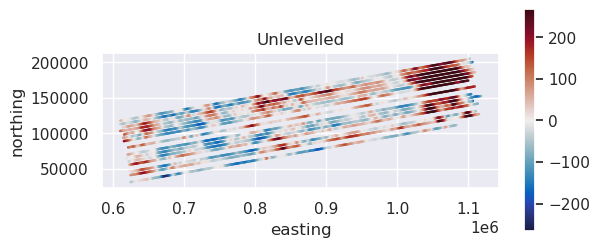

In [17]:
max_abs = vd.maxabs(data_df.mag_unlevelled, percentile=95)

ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="mag_unlevelled",
    s=0.6,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.6)
plt.show()

## Perform iterative equivalent source levelling

This function will go through each line and perform the following steps:
1) find the data within `max_dist` of the line data (exluding the line data itself)
2) fit equivalent sources to this nearby data (with the provided `damping`, `depth`, and `block_size` parameters)
3) predict the forward effect of these equivalent sources onto the line
4) compute a misfit between the observed and predicted values
5) fit a trend ff the specified `degree` (0 for DC-shift, 1 for tilt, 2 for curve etc.)
6) add this trend to the observed line data.  

This results in a levelled line. The algorithm then processed to the next line. The order it goes through the lines is randomized, as set by the `seed` parameter for reproducibility. by default, all lines with be levelled. If you only want to level a subset of lines, you can pass a list of line names to parameter `lines_to_level`. Once all (or subset of) lines are levelled, this concludes the first iteration. The entire processed can be repeated by setting parameter `max_iterations` to greater than 1. 

The iterations will terminate on one of 4 stopping criteria:
1) the `max_iterations` is reached
2) the root mean square (RMS) of the levelling correction values for the iteration is below the set `rms_tolerance`
3) the RMS of the levelling correction values has increased more than the set `rms_percent_increase_tolerance` relative to the minimum RMS value for past iterations; this helps to stop run-away iterations
4) the RMS of the levelling correction values has not changed by more than the set `rms_percent_change_tolerance` between 2 subsequent iterations; this help save time by ending iterations when they aren't offering much improvement.

Iteration: 5:  80%|████████  | 4/5 [00:50<00:13, 13.03s/it]WARNING:airbornegeo:
Equivalent source levelling terminated after 5 iterations with RMS of levelling correction of 6.58 because maximum number of iterations (5) reached.
Iterations ended due to ['max iterations']:  80%|████████  | 4/5 [01:01<00:15, 15.45s/it]


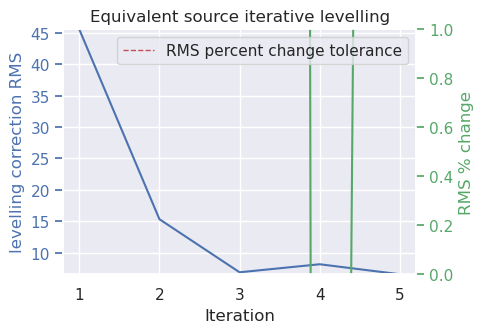

,easting,northing,height,line,distance_along_line,mag_unlevelled,mag_levelled
300335,1.101638e+06,204725.949316,4292.50,75,0.000000,-70.015,89.446703
300336,1.101482e+06,204674.286358,4293.25,75,164.076670,-49.095,110.166400
300337,1.101385e+06,204641.863294,4293.60,75,266.610209,-47.690,111.446292
300338,1.101320e+06,204620.197626,4293.80,75,335.043395,-46.700,112.352820
300339,1.101223e+06,204587.587218,4293.95,75,437.550594,-45.200,113.727826


In [31]:
data_df["mag_levelled"] = airbornegeo.equivalent_source_levelling(
    data_df,
    "mag_unlevelled",
    degree=2,
    max_dist=20e3,
    damping=None,
    depth="default",
    block_size=20e3,
    max_iterations=5,
)
data_df.head()

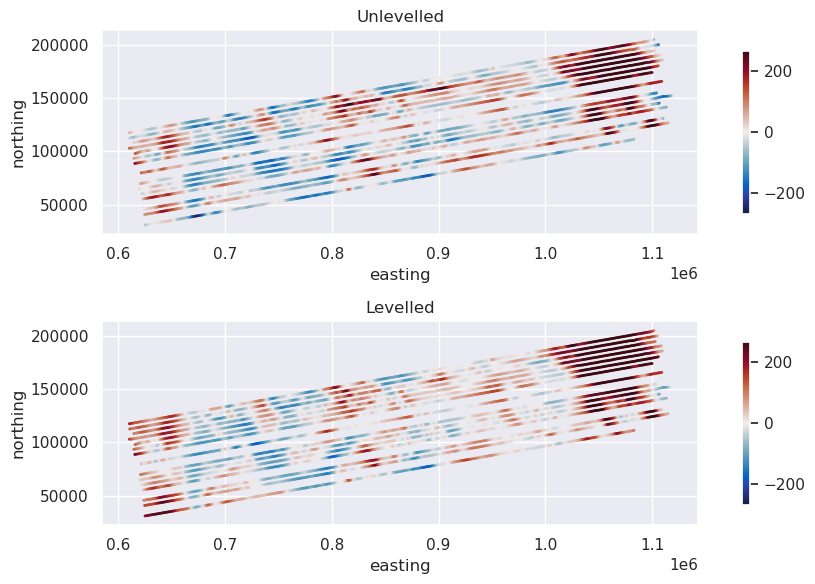

In [27]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6))

max_abs = vd.maxabs(data_df.mag_unlevelled, percentile=95)

ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="mag_unlevelled",
    s=1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.8)

ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="mag_levelled",
    s=1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Levelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()